In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
import pandas as pd
import numpy as np

In [59]:
url = "https://raw.githubusercontent.com/swapnilsaurav/Dataset/master/hotel_bookings.csv"

df = pd.read_csv(url)

df.head()

,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0.0,342.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,01-07-2015
1,2,Resort Hotel,0.0,737.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,10.0,Check-Out,01-07-2015
2,3,Resort Hotel,0.0,7.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
3,4,Resort Hotel,0.0,13.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
4,5,Resort Hotel,0.0,14.0,2015,July,27.0,1.0,0.0,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,03-07-2015


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              119390 non-null  int64  
 1   hotel                           119390 non-null  str    
 2   is_canceled                     119380 non-null  float64
 3   lead_time                       119380 non-null  float64
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  str    
 6   arrival_date_week_number        119376 non-null  float64
 7   arrival_date_day_of_month       119376 non-null  float64
 8   stays_in_weekend_nights         119376 non-null  float64
 9   stays_in_week_nights            119376 non-null  float64
 10  adults                          119376 non-null  float64
 11  children                        116929 non-null  float64
 12  babies                     

In [61]:
df.isnull().sum()

id                                     0
hotel                                  0
is_canceled                           10
lead_time                             10
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number              14
arrival_date_day_of_month             14
stays_in_weekend_nights               14
stays_in_week_nights                  14
adults                                14
children                            2461
babies                             13517
meal                               13703
country                              502
market_segment                        14
distribution_channel                  14
is_repeated_guest                     14
previous_cancellations                14
previous_bookings_not_canceled        14
reserved_room_type                    14
assigned_room_type                    14
booking_changes                       14
deposit_type                        9842
agent           

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df["adr"].describe()

count    119376.000000
mean        101.829793
std          50.534788
min          -6.380000
25%          69.280000
50%          94.510000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [64]:
df["adr"].isnull().sum()

np.int64(14)

In [65]:
df = df.dropna(subset=["adr"])

In [165]:
print("Missing ADR values:", df["adr"].isna().sum())
print("Dataset shape:", df.shape)

Missing ADR values: 0
Dataset shape: (119374, 33)


In [66]:
df["adr"].isnull().sum()

np.int64(0)

In [67]:
df.shape

(119376, 33)

In [68]:
df.isnull().sum()

id                                     0
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                            2447
babies                             13503
meal                               13689
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                        9828
agent           

In [69]:
df["children"] = df["children"].fillna(0)
df["babies"] = df["babies"].fillna(0)

df["meal"] = df["meal"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["deposit_type"] = df["deposit_type"].fillna("Unknown")

df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

In [166]:
print("Missing values after cleaning:")
print(df[[
    "children",
    "babies",
    "meal",
    "country",
    "deposit_type",
    "agent",
    "company"
]].isna().sum())

Missing values after cleaning:
children        0
babies          0
meal            0
country         0
deposit_type    0
agent           0
company         0
dtype: int64


In [70]:
df.isnull().sum()

id                                0
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type               

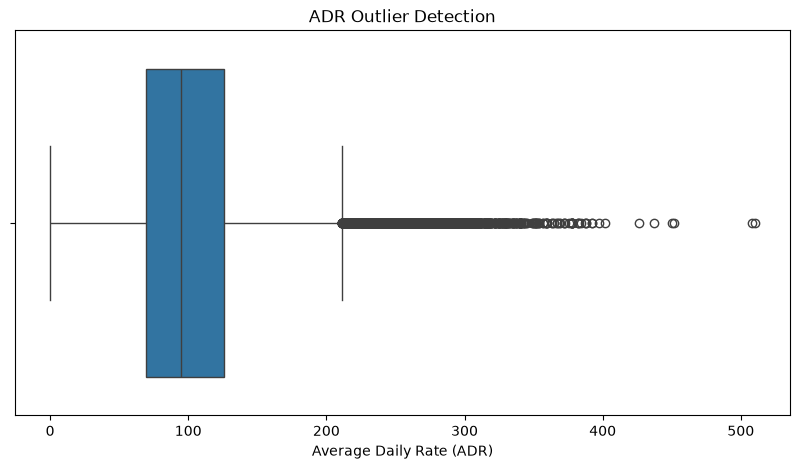

In [157]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["adr"])

plt.title("ADR Outlier Detection")
plt.xlabel("Average Daily Rate (ADR)")
plt.show()

In [72]:
df[df["adr"] < 0][["adr"]]

,adr
14969,-6.38


In [73]:
df[df["adr"] > 1000][["adr"]]

,adr
48515,5400.0


In [74]:
df = df[df["adr"] >= 0]

In [167]:
print("Minimum ADR:", df["adr"].min())
print("Dataset shape:", df.shape)

Minimum ADR: 0.0
Dataset shape: (119374, 33)


In [75]:
df = df[df["adr"] <= 1000]

In [168]:
print("Maximum ADR:", df["adr"].max())
print("Dataset shape:", df.shape)

Maximum ADR: 510.0
Dataset shape: (119374, 33)


In [76]:
df["adr"].describe()

count    119374.000000
mean        101.786316
std          48.151399
min           0.000000
25%          69.290000
50%          94.510000
75%         126.000000
max         510.000000
Name: adr, dtype: float64

In [77]:
df.shape

(119374, 33)

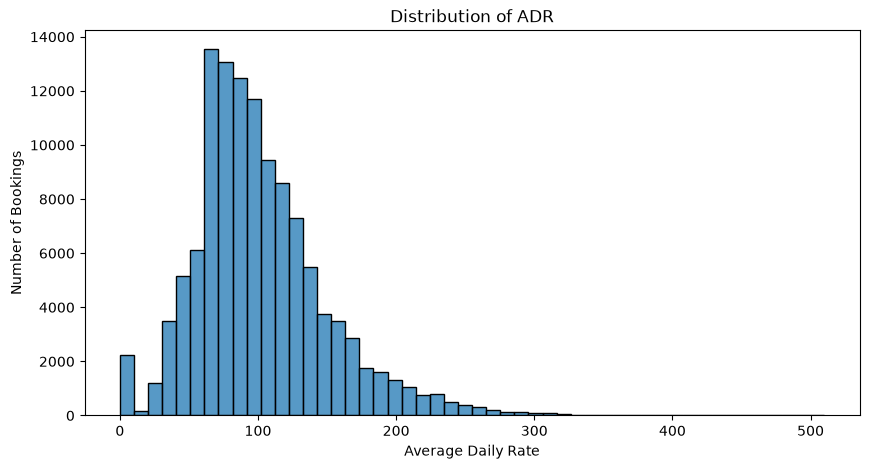

In [78]:
plt.figure(figsize=(10, 5))

sns.histplot(df["adr"], bins=50)

plt.title("Distribution of ADR")
plt.xlabel("Average Daily Rate")
plt.ylabel("Number of Bookings")
plt.show()

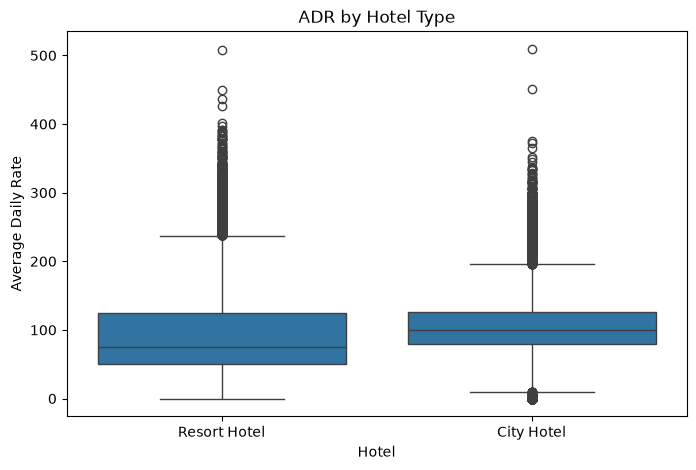

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="hotel", y="adr", data=df)

plt.title("ADR by Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("Average Daily Rate")
plt.show()

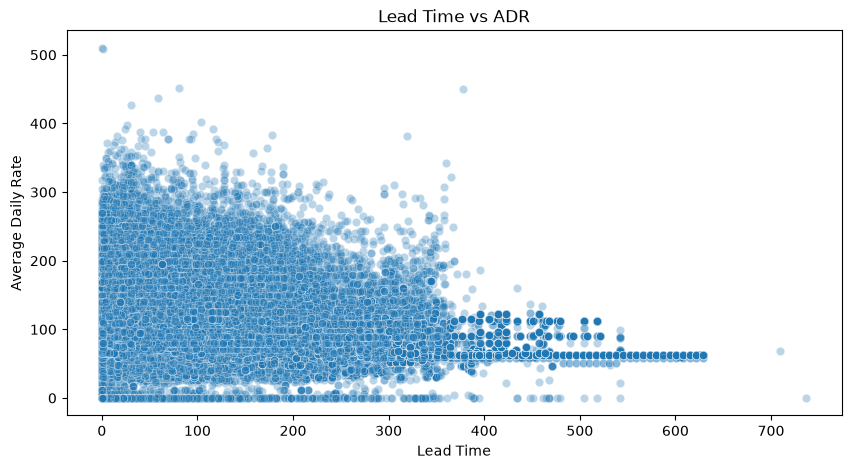

In [80]:
plt.figure(figsize=(10, 5))

sns.scatterplot(x="lead_time", y="adr", data=df, alpha=0.3)

plt.title("Lead Time vs ADR")
plt.xlabel("Lead Time")
plt.ylabel("Average Daily Rate")
plt.show()

In [81]:
df.columns

Index(['id', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [82]:
X = df.drop("adr", axis=1)
y = df["adr"]

In [169]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119374, 1178)
y shape: (119374,)


In [83]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119374, 32)
y shape: (119374,)


In [84]:
categorical_cols = X.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')


/var/folders/vs/63nnm01j1xjbmtn21537844m0000gn/T/ipykernel_1458/3236349369.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [85]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [170]:
print("X shape after encoding:", X.shape)
print("Data type check:")
print(X.dtypes.value_counts())

X shape after encoding: (119374, 1178)
Data type check:
bool       1158
float64      18
int64         2
Name: count, dtype: int64


In [86]:
print("X shape:", X.shape)

X shape: (119374, 1178)


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [88]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (95499, 1178)
X_test: (23875, 1178)
y_train: (95499,)
y_test: (23875,)


In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [172]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (95499, 1178)
X_test_scaled shape: (23875, 1178)


In [90]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [91]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

In [173]:
print("Ridge Regression prediction completed")
print("Number of predictions:", len(y_pred_ridge))

Ridge Regression prediction completed
Number of predictions: 23875


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Results
MAE: 20.767463790011142
MSE: 816.9563202449002
RMSE: 28.58244776510403
R2 Score: 0.6371293654632555


In [93]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [94]:
y_pred_rf = rf_model.predict(X_test)

In [174]:
print("Random Forest prediction completed")
print("Number of predictions:", len(y_pred_rf))

Random Forest prediction completed
Number of predictions: 23875


In [95]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression Results
MAE: 7.505214102617804
MSE: 263.718080950929
RMSE: 16.239399032936195
R2 Score: 0.8828633245106796


In [96]:
print("Random Forest Regression Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression Results
MAE: 7.505214102617804
MSE: 263.718080950929
RMSE: 16.239399032936195
R2 Score: 0.8828633245106796


In [97]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression Results
MAE: 7.505214102617804
MSE: 263.718080950929
RMSE: 16.239399032936195
R2 Score: 0.8828633245106796


In [98]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression Results
MAE: 7.505214102617804
MSE: 263.718080950929
RMSE: 16.239399032936195
R2 Score: 0.8828633245106796


In [99]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [105]:
y_pred_gb = gb_model.predict(X_test)

In [101]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regression Results")
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Regression Results
MAE: 16.87679363849711
MSE: 569.1892331850631
RMSE: 23.85768708791913
R2 Score: 0.747181026575042


In [110]:
print("Prediction completed")
print("Number of predictions:", len(y_pred_gb))

Prediction completed
Number of predictions: 23875


In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regression Results")
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)

Gradient Boosting Regression Results
MAE: 16.87679363849711
MSE: 569.1892331850631
RMSE: 23.85768708791913
R² Score: 0.747181026575042


In [113]:
print(df.columns)

Index(['id', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


In [114]:
# Classification - Predict Hotel Booking Cancellation

# Target variable
y_class = df["is_canceled"]

# Select numerical features
X_class = df[
    [
        "lead_time",
        "arrival_date_year",
        "arrival_date_week_number",
        "arrival_date_day_of_month",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adults",
        "children",
        "babies",
        "is_repeated_guest",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "booking_changes",
        "days_in_waiting_list",
        "adr",
        "required_car_parking_spaces",
        "total_of_special_requests"
    ]
]

print("Classification data prepared")
print("Features:", X_class.shape)
print("Target:", y_class.shape)

Classification data prepared
Features: (119374, 17)
Target: (119374,)


In [115]:
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training data:", X_train_class.shape)
print("Testing data:", X_test_class.shape)

Training data: (95499, 17)
Testing data: (23875, 17)


In [116]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_class, y_train_class)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [117]:
y_pred_class = logistic_model.predict(X_test_class)

print("Classification prediction completed")
print("Number of predictions:", len(y_pred_class))

Classification prediction completed
Number of predictions: 23875


In [118]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_class = accuracy_score(y_test_class, y_pred_class)

print("Logistic Regression Classification Results")
print("Accuracy:", accuracy_class)

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_class))

Logistic Regression Classification Results
Accuracy: 0.7266178010471204

Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.91      0.81     15031
         1.0       0.72      0.42      0.53      8844

    accuracy                           0.73     23875
   macro avg       0.73      0.66      0.67     23875
weighted avg       0.73      0.73      0.71     23875


Confusion Matrix:
[[13612  1419]
 [ 5108  3736]]


In [119]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for clustering
X_cluster = df[
    [
        "lead_time",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adults",
        "children",
        "babies",
        "adr",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "booking_changes",
        "days_in_waiting_list",
        "required_car_parking_spaces",
        "total_of_special_requests"
    ]
].copy()

# Handle missing values
X_cluster = X_cluster.fillna(0)

# Scale the data
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Clustering data prepared")
print("Clustering data shape:", X_cluster_scaled.shape)

Clustering data prepared
Clustering data shape: (119374, 13)


In [120]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_cluster_scaled)

print("K-Means clustering completed")
print("Number of clusters:", kmeans.n_clusters)

K-Means clustering completed
Number of clusters: 3


In [125]:
cluster_labels = kmeans.predict(X_cluster_scaled)

print("Cluster assignment completed")
print("Number of cluster labels:", len(cluster_labels))
print("Unique clusters:", set(cluster_labels))

Cluster assignment completed
Number of cluster labels: 119374
Unique clusters: {np.int32(0), np.int32(1), np.int32(2)}


In [153]:
from sklearn.metrics import silhouette_score

# Use 10,000 samples for faster calculation
sample_size = 10000

X_sample = X_cluster_scaled[:sample_size]
labels_sample = cluster_labels[:sample_size]

silhouette_avg = silhouette_score(
    X_sample,
    labels_sample
)

print("K-Means Clustering Results")
print("Silhouette Score:", silhouette_avg)

K-Means Clustering Results
Silhouette Score: 0.16071696779173247


In [154]:
print("X_cluster_scaled shape:", X_cluster_scaled.shape)
print("cluster_labels length:", len(cluster_labels))
print("K-Means object:", kmeans)

X_cluster_scaled shape: (119374, 13)
cluster_labels length: 119374
K-Means object: KMeans(n_clusters=3, n_init=10, random_state=42)


In [159]:
sample_size = 10000

X_sample = X_cluster_scaled[:sample_size]
labels_sample = cluster_labels[:sample_size]

silhouette_avg = silhouette_score(
    X_sample,
    labels_sample
)

In [160]:
print("K-Means Clustering Results")
print("Silhouette Score:", silhouette_avg)

K-Means Clustering Results
Silhouette Score: 0.16071696779173247


In [161]:
print(silhouette_avg)

0.16071696779173247


In [162]:
print("K-Means Clustering Results")
print("Silhouette Score:", silhouette_avg)

K-Means Clustering Results
Silhouette Score: 0.16071696779173247


In [163]:
print(silhouette_avg)

0.16071696779173247


In [164]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print("Bookings in each cluster:")
print(cluster_counts)

Bookings in each cluster:
0    40715
1     8137
2    70522
Name: count, dtype: int64
